<a href="https://colab.research.google.com/github/rymadinari/-arene-des-algos-Ryma-Dinari-/blob/main/arene.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# Phase 1 : Charger et explorer le dataset
from sklearn.datasets import load_breast_cancer
import numpy as np

def explorer_dataset():

    # Charger le dataset
    X, y = load_breast_cancer(return_X_y=True)
    dataset = load_breast_cancer()

    # Afficher la forme de X
    lignes, colonnes = X.shape
    print(f"Lignes, colonnes : {X.shape}")

    # Compter et afficher les exemples par classe
    for i, nom_classe in enumerate(dataset.target_names):
        nb = np.sum(y == i)
        pct = nb / len(y) * 100
        print(f"Classe {i} ({nom_classe}) : {nb} cas ({pct:.1f}%)")


    #Checkpoint 1 — cas normal
    counts = [np.sum(y == i) for i in range(len(dataset.target_names))]
    max_pct = max(counts) / len(y) * 100
    if max_pct > 70:
        print(f"Dataset déséquilibré ! La classe majoritaire représente {max_pct:.1f}%")
    else:
        print("Dataset relativement équilibré")

    return X, y

X, y = explorer_dataset()

Lignes, colonnes : (569, 30)
Classe 0 (malignant) : 212 cas (37.3%)
Classe 1 (benign) : 357 cas (62.7%)
Dataset relativement équilibré


In [14]:
# Checkpoint 2 — cas limite : une seule classe
print("Checkpoint : une seule classe ")
X_filtre = X[y == 0]
y_filtre = y[y == 0]
print(f"Forme après filtre : {X_filtre.shape}")
print(f"Classes présentes : {np.unique(y_filtre)}")

# Checkpoint 3 — cas adversarial : dataset déséquilibré artificiel
print("Checkpoint : dataset déséquilibré (95/5)")
y_fake = np.array([0] * 950 + [1] * 50)
for i in range(2):
    nb = np.sum(y_fake == i)
    pct = nb / len(y_fake) * 100
    print(f"Classe {i} : {nb} cas ({pct:.1f}%)")
max_pct = max([np.sum(y_fake == i) for i in range(2)]) / len(y_fake) * 100
if max_pct > 70:
    print(f"Déséquilibré ! Classe majoritaire : {max_pct:.1f}%")

Checkpoint : une seule classe 
Forme après filtre : (212, 30)
Classes présentes : [0]
Checkpoint : dataset déséquilibré (95/5)
Classe 0 : 950 cas (95.0%)
Classe 1 : 50 cas (5.0%)
Déséquilibré ! Classe majoritaire : 95.0%


In [16]:
# Phase 2 : Pipeline supervisé complet
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

def entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test):

    modele.fit(X_train, y_train)

    y_pred = modele.predict(X_test)

    return accuracy_score(y_test, y_pred)



# Charger les données de la phase 1
X, y = explorer_dataset()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train : {X_train.shape[0]} exemples")
print(f"Test  : {X_test.shape[0]} exemples")

# Tester avec un arbre de décision
modele = DecisionTreeClassifier(random_state=42)
acc = entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test)
print(f"\nAccuracy arbre de décision : {acc*100:.1f}%")

Lignes, colonnes : (569, 30)
Classe 0 (malignant) : 212 cas (37.3%)
Classe 1 (benign) : 357 cas (62.7%)
Dataset relativement équilibré
Train : 455 exemples
Test  : 114 exemples

Accuracy arbre de décision : 94.7%


In [21]:
# Phase 3 : L'Arène — classement de plusieurs algos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

def arene(X_train, X_test, y_train, y_test):

    modeles = {
        "Régression logistique" : LogisticRegression(max_iter=10000, random_state=42),
        "KNN"                   : KNeighborsClassifier(),
        "Arbre de décision"     : DecisionTreeClassifier(random_state=42),
    }

    resultats = {}
    for nom, modele in modeles.items():
        acc = entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test)
        resultats[nom] = acc

    # trier par accuracy décroissante et afficher le podium
    classement = sorted(resultats.items(), key=lambda x: x[1], reverse=True)

    for rang, (nom, acc) in enumerate(classement, start=1):
        print(f"{rang:<6} {nom:<25} {acc*100:>7.1f}%")

    return classement


#  Lancer l'Arène
classement = arene(X_train, X_test, y_train, y_test)

1      Régression logistique        95.6%
2      KNN                          95.6%
3      Arbre de décision            94.7%


In [23]:
# Phase 4 : Clustering non supervisé (KMeans)
from sklearn.cluster import KMeans
import numpy as np

def clustering_aveugle(X):
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    return kmeans.fit_predict(X)


# Lancer le clustering
clusters = clustering_aveugle(X)

# Comparer avec les vraies étiquettes
from sklearn.metrics import adjusted_rand_score

score = adjusted_rand_score(y, clusters)
print(f"Score de similarité clusters vs vraies classes : {score:.3f}")

print("Correspondance clusters → vraies classes :")
for cluster in [0, 1]:
    masque = clusters == cluster
    nb_malin  = np.sum(y[masque] == 0)
    nb_benin  = np.sum(y[masque] == 1)
    total     = np.sum(masque)
    print(f"Cluster {cluster} ({total} points) : {nb_malin} malignes · {nb_benin} bénignes")

Score de similarité clusters vs vraies classes : 0.491
Correspondance clusters → vraies classes :
Cluster 0 (131 points) : 130 malignes · 1 bénignes
Cluster 1 (438 points) : 82 malignes · 356 bénignes


In [28]:
# Phase 5 : Changer de terrain — dataset Wine (3 classes)
from sklearn.datasets import load_wine

# Charger nouveau dataset
X_wine, y_wine = load_wine(return_X_y=True)
dataset_wine = load_wine()

print(f"Lignes, colonnes : {X_wine.shape}")
print()
for i, nom in enumerate(dataset_wine.target_names):
    nb  = np.sum(y_wine == i)
    pct = nb / len(y_wine) * 100
    print(f"Classe {i} ({nom}) : {nb} cas ({pct:.1f}%)")

# Split
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42
)

print("Arène sur Wine")
classement_wine = arene(X_train_w, X_test_w, y_train_w, y_test_w)

Lignes, colonnes : (178, 13)

Classe 0 (class_0) : 59 cas (33.1%)
Classe 1 (class_1) : 71 cas (39.9%)
Classe 2 (class_2) : 48 cas (27.0%)
Arène sur Wine
1      Régression logistique       100.0%
2      Arbre de décision            94.4%
3      KNN                          72.2%


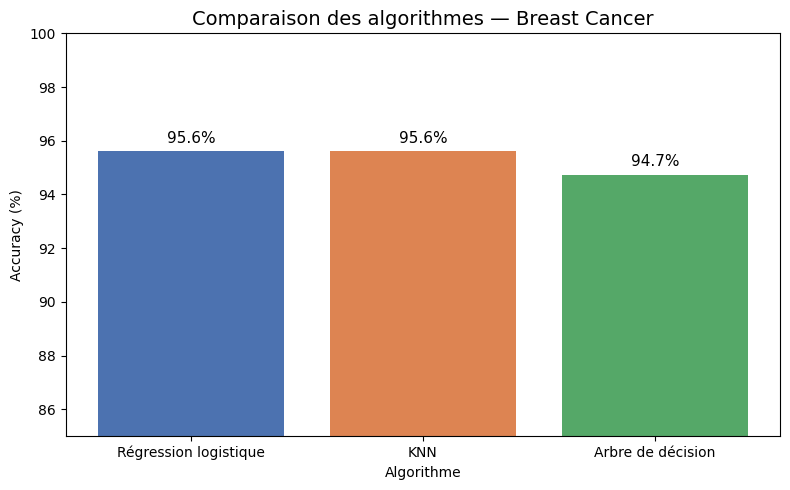

Graphique sauvegardé : arene_breast_cancer.png


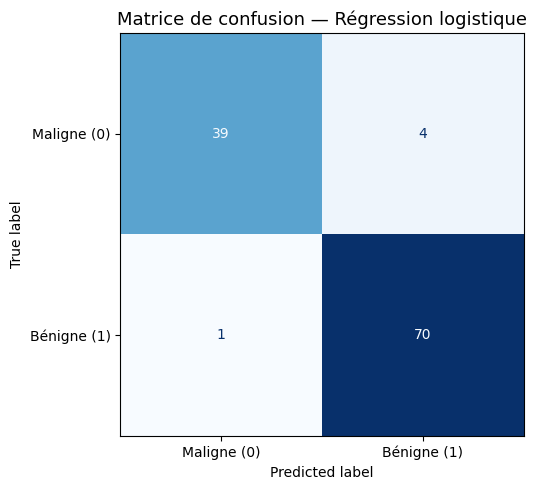

Matrice sauvegardée : confusion_matrix.png


In [32]:
# PHASE 6 : Visualisations
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Graphique 1 : Barplot des accuracies
noms = [nom for nom, _ in classement]
accs = [acc * 100 for _, acc in classement]

plt.figure(figsize=(8, 5))
barres = plt.bar(noms, accs, color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Comparaison des algorithmes — Breast Cancer", fontsize=14)
plt.ylabel("Accuracy (%)")
plt.xlabel("Algorithme")
plt.ylim(85, 100)

# Afficher la valeur
for barre, acc in zip(barres, accs):
    plt.text(
        barre.get_x() + barre.get_width() / 2,
        barre.get_height() + 0.2,
        f"{acc:.1f}%",
        ha="center", va="bottom", fontsize=11
    )

plt.tight_layout()
plt.savefig("arene_breast_cancer.png", dpi=150)
plt.show()
print("Graphique sauvegardé : arene_breast_cancer.png")


# Graphique 2 : Matrice de confusion du champion(régression logistique)
champion = LogisticRegression(max_iter=10000, random_state=42)
champion.fit(X_train, y_train)
y_pred = champion.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Maligne (0)", "Bénigne (1)"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matrice de confusion — Régression logistique", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Matrice sauvegardée : confusion_matrix.png")

In [34]:
# PHASE 7 : Scaling + Data Leakage
from sklearn.preprocessing import StandardScaler

def comparer_scaling(modeles, X_train, X_test, y_train, y_test):

    # Préparer le scaler — fitté sur le TRAIN uniquement
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    print("=" * 58)
    print(f"{'Algo':<25} {'Brut':>7} {'Scalé':>7} {'Gain':>8}")
    print("=" * 58)

    resultats = []
    for nom, modele in modeles.items():
        # Sans scaling
        acc_brut  = entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test)
        # Avec scaling (même modèle, données différentes)
        acc_scale = entrainer_et_evaluer(modele, X_train_scaled, X_test_scaled, y_train, y_test)
        gain      = (acc_scale - acc_brut) * 100
        resultats.append((nom, acc_brut, acc_scale, gain))

    # Trier par gain décroissant
    resultats.sort(key=lambda x: x[3], reverse=True)

    for nom, brut, scale, gain in resultats:
        signe = "+" if gain >= 0 else ""
        print(f"{nom:<25} {brut*100:>6.1f}% {scale*100:>6.1f}% {signe}{gain:>6.1f}pp")

    print("=" * 58)
    return resultats


# Manche 1 : le buff honnête
modeles = {
    "Régression logistique" : LogisticRegression(max_iter=10000, random_state=42),
    "KNN"                   : KNeighborsClassifier(),
    "Arbre de décision"     : DecisionTreeClassifier(random_state=42),
}

print("MANCHE 1 — Scaling honnête (fit sur train seul)\n")
resultats_scaling = comparer_scaling(modeles, X_train, X_test, y_train, y_test)


# --- Manche 2 : la triche (data leakage volontaire) ---
print("\nMANCHE 2 — Triche : scaler fitté sur TOUT X\n")

scaler_triche = StandardScaler()
scaler_triche.fit(X)                              # voit les données de test
X_train_triche = scaler_triche.transform(X_train)
X_test_triche  = scaler_triche.transform(X_test)

champion_triche = LogisticRegression(max_iter=10000, random_state=42)
acc_triche = entrainer_et_evaluer(
    champion_triche,
    X_train_triche, X_test_triche,
    y_train, y_test
)

# Accuracy honnête du champion scalé
scaler_honnete = StandardScaler()
X_train_h = scaler_honnete.fit_transform(X_train)
X_test_h  = scaler_honnete.transform(X_test)
champion_honnete = LogisticRegression(max_iter=10000, random_state=42)
acc_honnete = entrainer_et_evaluer(
    champion_honnete,
    X_train_h, X_test_h,
    y_train, y_test
)

mensonge = (acc_triche - acc_honnete) * 100
print(f"Accuracy honnête  : {acc_honnete*100:.1f}%")
print(f"Accuracy trichée  : {acc_triche*100:.1f}%")
print(f"Mensonge          : +{mensonge:.1f} points de pourcentage")

MANCHE 1 — Scaling honnête (fit sur train seul)

Algo                         Brut   Scalé     Gain
Régression logistique       95.6%   97.4% +   1.8pp
Arbre de décision           94.7%   94.7% +   0.0pp
KNN                         95.6%   94.7%   -0.9pp

MANCHE 2 — Triche : scaler fitté sur TOUT X

Accuracy honnête  : 97.4%
Accuracy trichée  : 97.4%
Mensonge          : +0.0 points de pourcentage
